In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/baseline-artifacts/thresholds.json
/kaggle/input/baseline-artifacts/df_resid.parquet
/kaggle/input/baseline-artifacts/df_pred.parquet
/kaggle/input/baseline-artifacts/df_wide.parquet
/kaggle/input/caf-dataset/CAF_sensors.dbf
/kaggle/input/caf-dataset/Hourly/Hourly/CAF141.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF019.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF209.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF007.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF397.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF237.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF205.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF125.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF139.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF095.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF201.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF215.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF079.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF231.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF275.

# Data and Preprocessing

In [2]:
# ================= CONFIG =================
SEED = 42
WINDOW = 24
K_NEIGHBORS = 4

import numpy as np
import pandas as pd
import torch
import random

np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)


In [3]:
# ================= DATA LOAD =================
df_wide = pd.read_parquet(
    "/kaggle/input/baseline-artifacts/df_wide.parquet"
)

df_wide = df_wide.sort_index()
sensor_ids = df_wide.columns.tolist()

T, N = df_wide.shape
print("Time steps:", T)
print("Sensors:", N)


Time steps: 66705
Sensors: 10


In [4]:
# ================= MISSING DATA =================
df_filled = df_wide.interpolate(limit_direction="both")
df_filled = df_filled.fillna(df_filled.mean())

assert not df_filled.isna().any().any(), "❌ NaNs still present"


In [5]:
# ================= NORMALIZATION =================
X_np = df_filled.values.astype(np.float32)

mean = X_np.mean()
std  = X_np.std() + 1e-6

X_np = (X_np - mean) / std
X = torch.tensor(X_np, dtype=torch.float32)

assert torch.isfinite(X).all(), "❌ Non-finite values"


In [6]:
# ================= SENSOR METADATA =================
import geopandas as gpd

DBF_PATH = "/kaggle/input/caf-dataset/CAF_sensors.dbf"
gdf = gpd.read_file(DBF_PATH)

sensor_meta = gdf[["Location", "Easting", "Northing"]].copy()

coords = (
    sensor_meta
    .set_index("Location")
    .loc[sensor_ids][["Easting", "Northing"]]
    .values
)

assert coords.shape == (N, 2)


In [7]:
# ================= SPATIAL GRAPH =================
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=K_NEIGHBORS + 1).fit(coords)
distances, indices = nbrs.kneighbors(coords)

# Remove self-loops (first neighbor)
neighbors = indices[:, 1:]
neighbor_dist = distances[:, 1:]


In [8]:
# ================= DISTANCE-WEIGHTED ADJ =================
A = np.zeros((N, N), dtype=np.float32)

for i in range(N):
    for j, d in zip(neighbors[i], neighbor_dist[i]):
        A[i, j] = 1.0 / (d + 1e-6)
        A[j, i] = A[i, j]

# self-loops
np.fill_diagonal(A, 1.0)

# row-normalize
A = A / A.sum(axis=1, keepdims=True)

A = torch.tensor(A, dtype=torch.float32)

assert torch.allclose(A.sum(dim=1), torch.ones(N)), "❌ Bad normalization"


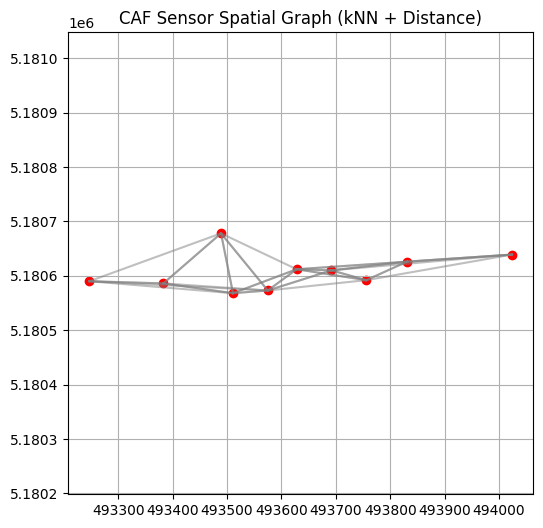

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(coords[:,0], coords[:,1], c="red")

for i in range(N):
    for j in neighbors[i]:
        plt.plot(
            [coords[i,0], coords[j,0]],
            [coords[i,1], coords[j,1]],
            color="gray", alpha=0.5
        )

plt.title("CAF Sensor Spatial Graph (kNN + Distance)")
plt.axis("equal")
plt.grid(True)
plt.show()


# Fault Injection

In [10]:
# ================= FAULT CONFIG =================
FAULT_SENSOR = 2
FAULT_START  = 20000
FAULT_END    = 20500
FAULT_MAG    = 5.0   # in normalized units


In [11]:
# ================= FAULT GROUND TRUTH =================
T, N = X.shape

fault_gt = torch.zeros((T, N), dtype=torch.bool)
fault_gt[FAULT_START:FAULT_END, FAULT_SENSOR] = True

print("Total faulted samples:", fault_gt.sum().item())


Total faulted samples: 500


In [12]:
# ================= FAULT INJECTION =================
X_fault = X.clone()
X_fault[FAULT_START:FAULT_END, FAULT_SENSOR] += FAULT_MAG

assert torch.isfinite(X_fault).all()


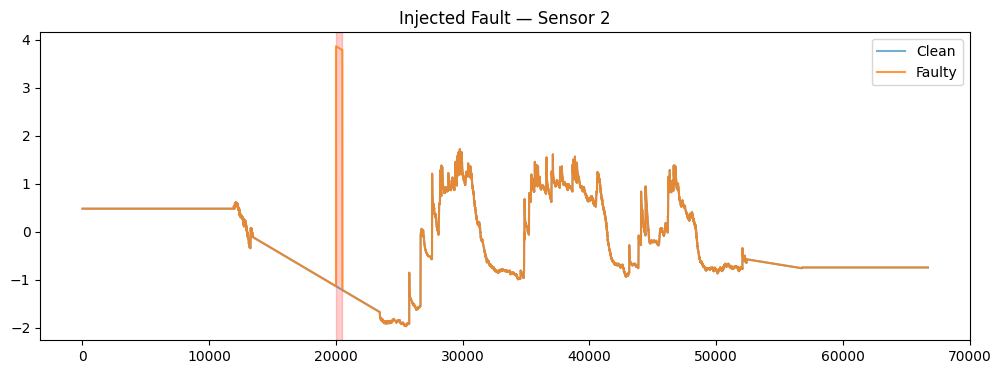

In [13]:
import matplotlib.pyplot as plt

s = FAULT_SENSOR

plt.figure(figsize=(12,4))
plt.plot(X[:, s].cpu(), label="Clean", alpha=0.6)
plt.plot(X_fault[:, s].cpu(), label="Faulty", alpha=0.8)

plt.axvspan(FAULT_START, FAULT_END, color="red", alpha=0.2)
plt.legend()
plt.title(f"Injected Fault — Sensor {s}")
plt.show()


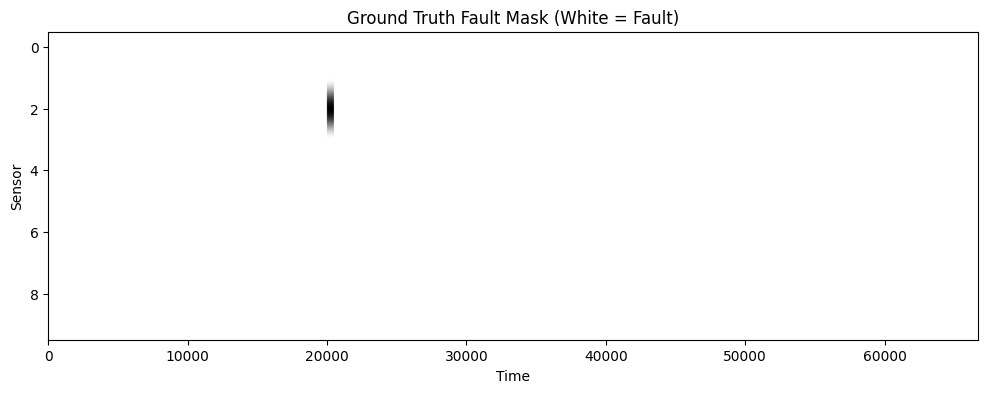

In [14]:
plt.figure(figsize=(12,4))
plt.imshow(
    fault_gt.T.cpu(),
    aspect="auto",
    cmap="gray_r"
)
plt.xlabel("Time")
plt.ylabel("Sensor")
plt.title("Ground Truth Fault Mask (White = Fault)")
plt.show()


In [15]:
# ================= SPATIAL BASELINE PREDICTOR =================
A_np = A.cpu().numpy()

def spatial_predictor(X, A):
    """
    X: (T, N)
    A: (N, N) adjacency (row-normalized)
    """
    return X @ A.T


In [16]:
# ================= PREDICTIONS & RESIDUALS =================
pred_spatial = spatial_predictor(X_fault, A)

residuals = torch.abs(X_fault - pred_spatial)
res_np = residuals.cpu().numpy()


In [17]:
assert residuals.shape == X.shape


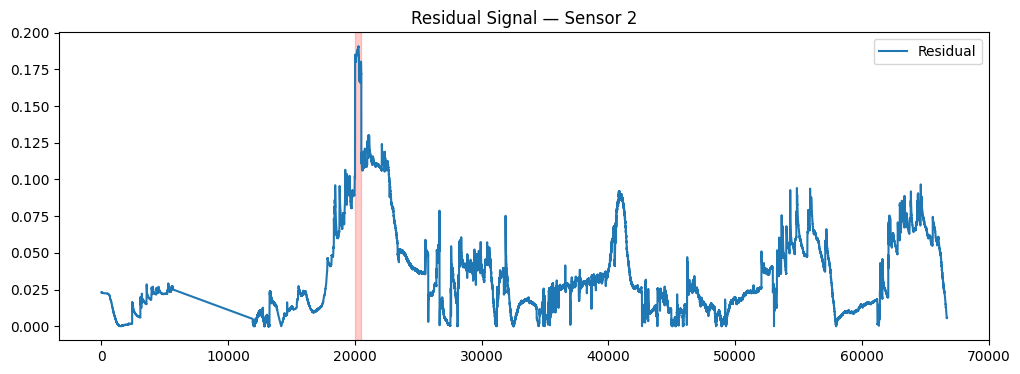

In [18]:
s = FAULT_SENSOR

plt.figure(figsize=(12,4))
plt.plot(res_np[:, s], label="Residual")
plt.axvspan(FAULT_START, FAULT_END, color="red", alpha=0.2)
plt.legend()
plt.title(f"Residual Signal — Sensor {s}")
plt.show()


In [19]:
# ================= ROBUST THRESHOLDS =================
res_np = residuals.cpu().numpy()

median = np.nanmedian(res_np, axis=0)
mad = np.nanmedian(np.abs(res_np - median), axis=0)

THRESH = median + 4.0 * mad   # conservative


In [20]:
# ================= RAW FAULT FLAGS =================
fault_flags_raw = res_np > THRESH


In [21]:
# ================= PERSISTENCE FILTER =================
W = 100   # window length
K = 60    # minimum positives

fault_flags = np.zeros_like(fault_flags_raw, dtype=bool)

for s in range(fault_flags_raw.shape[1]):
    conv = np.convolve(
        fault_flags_raw[:, s].astype(int),
        np.ones(W, dtype=int),
        mode="same"
    )
    fault_flags[:, s] = conv >= K


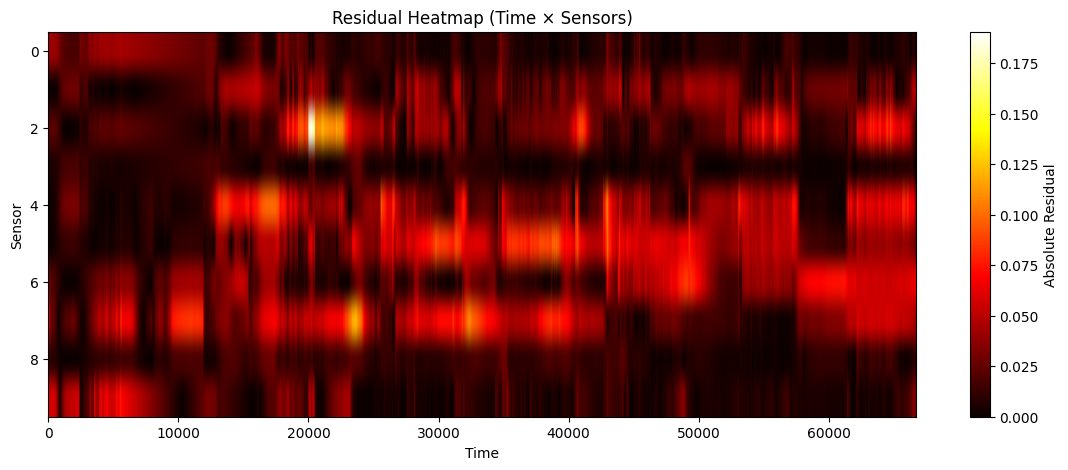

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.imshow(
    res_np.T,
    aspect="auto",
    cmap="hot"
)
plt.colorbar(label="Absolute Residual")
plt.xlabel("Time")
plt.ylabel("Sensor")
plt.title("Residual Heatmap (Time × Sensors)")
plt.show()


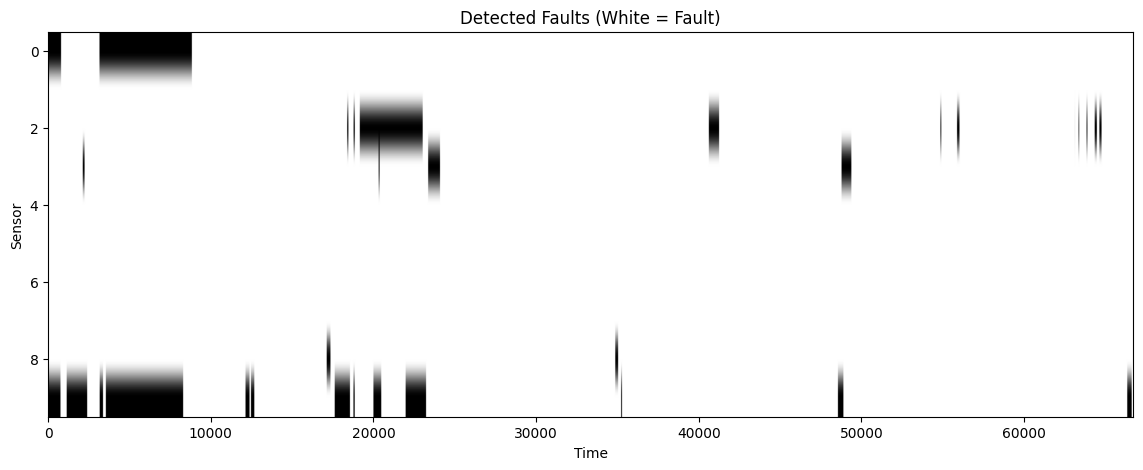

In [23]:
plt.figure(figsize=(14,5))
plt.imshow(
    fault_flags.T,
    aspect="auto",
    cmap="gray_r"
)
plt.xlabel("Time")
plt.ylabel("Sensor")
plt.title("Detected Faults (White = Fault)")
plt.show()


In [24]:
# ================= EVALUATION =================
gt = fault_gt.cpu().numpy()

TP = np.logical_and(fault_flags, gt).sum()
FP = np.logical_and(fault_flags, ~gt).sum()
FN = np.logical_and(~fault_flags, gt).sum()

precision = TP / (TP + FP + 1e-6)
recall    = TP / (TP + FN + 1e-6)

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")


Precision: 0.020
Recall:    1.000


In [25]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [26]:
# ========= GLOBAL CONFIG =========
sensor_idx = 2
W = 24
t_start = 20000
t_end = 20500
# ================================



# Temporal Only

In [27]:
class TemporalDataset(Dataset):
    def __init__(self, series, window):
        self.series = series
        self.window = window

    def __len__(self):
        return len(self.series) - self.window

    def __getitem__(self, i):
        x = self.series[i:i+self.window]
        y = self.series[i+self.window]
        return x.unsqueeze(-1), y


In [28]:
# ================= CLEAN & FAULT DATA =================

# Clean (normalized, no fault)
X_clean = X.clone()          # X was your normalized df_filled tensor

# Faulty (normalized, injected fault)
X_fault = X_fault.clone()    # from inject_bias(...)


In [29]:
print(X_clean.shape, X_fault.shape)
assert X_clean.shape == X_fault.shape


torch.Size([66705, 10]) torch.Size([66705, 10])


In [30]:
train_ds = TemporalDataset(X_clean[:, sensor_idx], W)
test_ds  = TemporalDataset(X_fault[:, sensor_idx], W)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)


In [31]:
class TemporalGRU(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.gru = nn.GRU(1, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        _, h = self.gru(x)
        return self.fc(h.squeeze(0)).squeeze(-1)


In [32]:
model = TemporalGRU()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()


In [33]:
for epoch in range(20):
    total = 0
    for x, y in train_loader:
        pred = model(x)
        loss = loss_fn(pred, y)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total += loss.item()

    print(f"Epoch {epoch+1}: {total/len(train_loader):.6f}")


Epoch 1: 0.016032
Epoch 2: 0.000284
Epoch 3: 0.000232
Epoch 4: 0.000201
Epoch 5: 0.000175
Epoch 6: 0.000155
Epoch 7: 0.000139
Epoch 8: 0.000131
Epoch 9: 0.000121
Epoch 10: 0.000116
Epoch 11: 0.000113
Epoch 12: 0.000106
Epoch 13: 0.000104
Epoch 14: 0.000105
Epoch 15: 0.000099
Epoch 16: 0.000099
Epoch 17: 0.000101
Epoch 18: 0.000100
Epoch 19: 0.000100
Epoch 20: 0.000100


In [34]:
model.eval()
preds = []

with torch.no_grad():
    for x, _ in test_loader:
        preds.append(model(x))

preds = torch.cat(preds)


In [35]:
# ================= TEMPORAL RECONSTRUCTION (CORRECT) =================

T, N = X_fault.shape
X_temp_hat = X_fault.clone()   # fallback is faulty signal

# preds shape: (T-W,) for single sensor
X_temp_hat[W:, sensor_idx] = preds.squeeze()

# sanity checks
assert X_temp_hat.shape == X_fault.shape
assert not torch.isnan(X_temp_hat).any()


In [36]:
true_clean = X_clean[W:, sensor_idx]
faulty_obs = X_fault[W:, sensor_idx]

rmse_faulty = torch.sqrt(((faulty_obs - true_clean)**2).mean())
rmse_temp   = torch.sqrt(((preds - true_clean)**2).mean())

print("RMSE faulty:", rmse_faulty.item())
print("RMSE temporal:", rmse_temp.item())


RMSE faulty: 0.4329661428928375
RMSE temporal: 0.3962700366973877


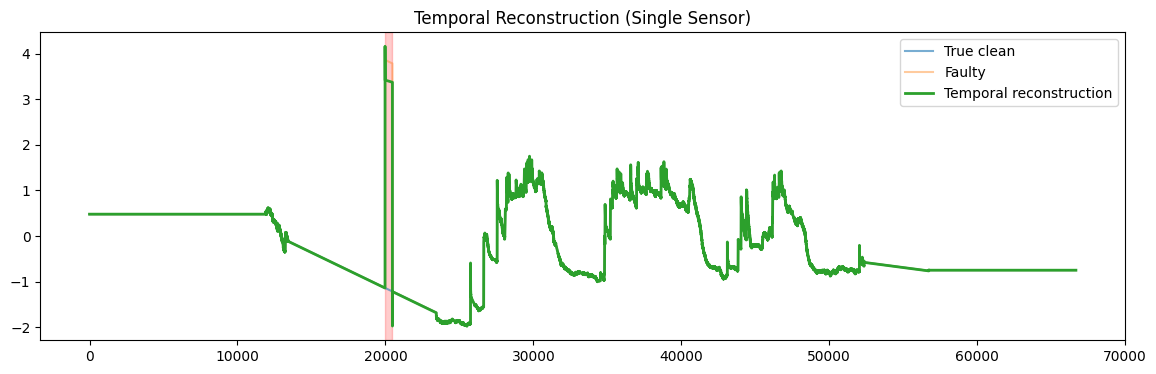

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.plot(true_clean, label="True clean", alpha=0.6)
plt.plot(faulty_obs, label="Faulty", alpha=0.4)
plt.plot(preds, label="Temporal reconstruction", linewidth=2)

plt.axvspan(t_start-W, t_end-W, color="red", alpha=0.2)
plt.legend()
plt.title("Temporal Reconstruction (Single Sensor)")
plt.show()


In [39]:
# ================= FAULT WINDOW MASK =================
mask_fault_window = torch.zeros(T, dtype=torch.bool)
mask_fault_window[FAULT_START:FAULT_END] = True

assert mask_fault_window.shape[0] == T


In [41]:
# ================= GROUND TRUTH =================
Y_true = X_clean

assert Y_true.shape == X_fault.shape


In [42]:
rmse_temporal_fault_window = torch.sqrt(
    torch.mean(
        (X_temp_hat[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)


# Spatial Only

In [43]:
import numpy as np

N = coords.shape[0]

# Pairwise distances
dist = np.linalg.norm(coords[:, None, :] - coords[None, :, :], axis=2)

# Avoid self-edges
np.fill_diagonal(dist, np.inf)

# Hyperparameters
K = 4            # number of neighbors
eps = 1e-6       # numerical stability

# Nearest neighbors per sensor
nbr_idx = np.argsort(dist, axis=1)[:, :K]   # (N, K)
nbr_dist = np.take_along_axis(dist, nbr_idx, axis=1)

# Inverse-distance weights
W_spatial = 1.0 / (nbr_dist + eps)
W_spatial = W_spatial / W_spatial.sum(axis=1, keepdims=True)


In [44]:
def spatial_reconstruct(X_obs, fault_flags, nbr_idx, W_spatial):
    """
    X_obs:        (T, N) observed (faulty) data
    fault_flags:  (T, N) boolean
    Returns:
        X_spatial_hat: (T, N)
    """
    T, N = X_obs.shape
    X_hat = X_obs.copy()

    for t in range(T):
        for s in range(N):
            if fault_flags[t, s]:
                neighbors = nbr_idx[s]
                weights = W_spatial[s]

                X_hat[t, s] = np.sum(
                    weights * X_obs[t, neighbors]
                )

    return X_hat


In [45]:
X_spatial_hat = spatial_reconstruct(
    X_fault.numpy(),
    fault_flags,
    nbr_idx,
    W_spatial
)

X_spatial_hat = torch.tensor(X_spatial_hat, dtype=torch.float32)


In [46]:
# True clean reference
Y_true = X_clean

# RMSE over full signal
rmse_spatial = torch.sqrt(
    torch.mean((X_spatial_hat - Y_true) ** 2)
)

print("RMSE spatial-only:", rmse_spatial.item())


RMSE spatial-only: 0.2994402050971985


In [47]:
mask_fault_window = torch.zeros(Y_true.shape[0], dtype=torch.bool)
mask_fault_window[t_start:t_end] = True

rmse_spatial_fault_window = torch.sqrt(
    torch.mean(
        (X_spatial_hat[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)

rmse_faulty_fault_window = torch.sqrt(
    torch.mean(
        (X_fault[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)

print("RMSE faulty (fault window):", rmse_faulty_fault_window.item())
print("RMSE spatial (fault window):", rmse_spatial_fault_window.item())


RMSE faulty (fault window): 5.0
RMSE spatial (fault window): 1.7880803346633911


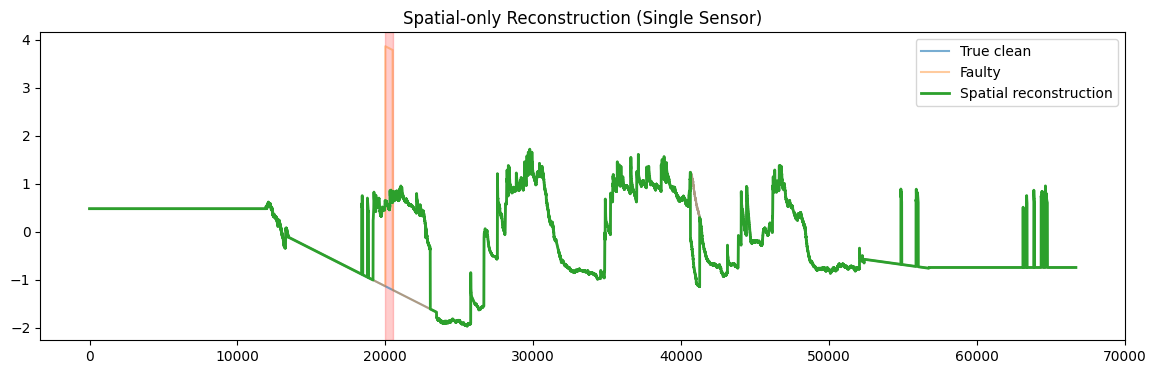

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.plot(Y_true[:, sensor_idx], label="True clean", alpha=0.6)
plt.plot(X_fault[:, sensor_idx], label="Faulty", alpha=0.4)
plt.plot(X_spatial_hat[:, sensor_idx], label="Spatial reconstruction", linewidth=2)

plt.axvspan(t_start, t_end, color="red", alpha=0.2)
plt.legend()
plt.title("Spatial-only Reconstruction (Single Sensor)")
plt.show()


In [49]:
rmse_spatial_fault_window = torch.sqrt(
    torch.mean(
        (X_spatial_hat[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)


# Rule-based Temporal + Spatial

In [50]:
def compute_trust_weights(fault_len, max_len=200):
    """
    fault_len: how long the current fault has lasted
    """
    # Temporal trust decays with fault duration
    alpha_temp = np.exp(-fault_len / max_len)
    alpha_spatial = 1.0 - alpha_temp
    return alpha_temp, alpha_spatial


In [51]:
def fuse_reconstruction(
    X_fault,
    X_temp_hat,
    X_spatial_hat,
    fault_flags
):
    T, N = X_fault.shape
    X_fused = X_fault.clone()

    fault_duration = np.zeros(N, dtype=int)

    for t in range(T):
        for s in range(N):
            if fault_flags[t, s]:
                fault_duration[s] += 1

                a_t, a_s = compute_trust_weights(fault_duration[s])
                X_fused[t, s] = (
                    a_t * X_temp_hat[t, s]
                    + a_s * X_spatial_hat[t, s]
                )
            else:
                fault_duration[s] = 0

    return X_fused


In [52]:
X_fused = fuse_reconstruction(
    X_fault,
    X_temp_hat,
    X_spatial_hat,
    fault_flags
)


In [53]:
rmse_fused_fault_window = torch.sqrt(
    torch.mean(
        (X_fused[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)


In [54]:
print("RMSE temporal (fault window):", rmse_temporal_fault_window.item())
print("RMSE spatial  (fault window):", rmse_spatial_fault_window.item())
print("RMSE fused    (fault window):", rmse_fused_fault_window.item())


RMSE temporal (fault window): 4.5700883865356445
RMSE spatial  (fault window): 1.7880803346633911
RMSE fused    (fault window): 1.8040649890899658


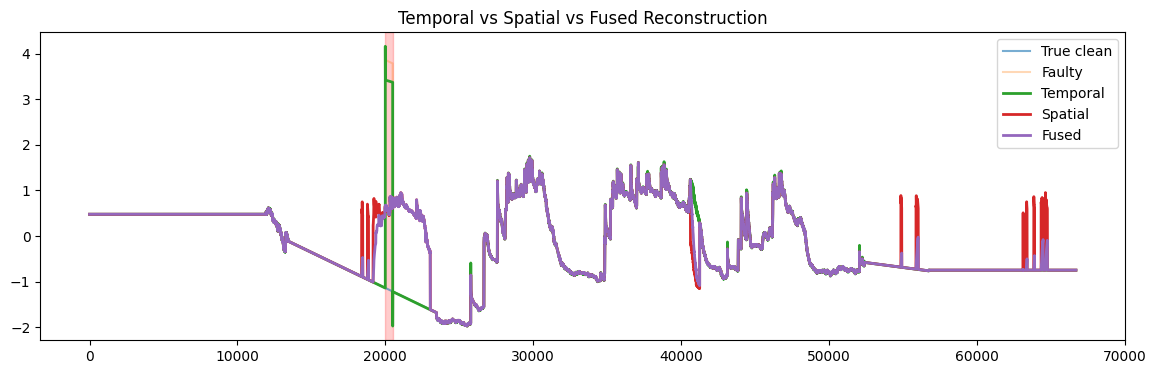

In [55]:
plt.figure(figsize=(14,4))
plt.plot(Y_true[:, sensor_idx], label="True clean", alpha=0.6)
plt.plot(X_fault[:, sensor_idx], label="Faulty", alpha=0.3)
plt.plot(X_temp_hat[:, sensor_idx], label="Temporal", linewidth=2)
plt.plot(X_spatial_hat[:, sensor_idx], label="Spatial", linewidth=2)
plt.plot(X_fused[:, sensor_idx], label="Fused", linewidth=2)

plt.axvspan(t_start, t_end, color="red", alpha=0.2)
plt.legend()
plt.title("Temporal vs Spatial vs Fused Reconstruction")
plt.show()


# Trust-Weighted Fusion

In [56]:
A_bin = (A > 0).float()
neighbors = {
    i: torch.where(A_bin[i])[0]
    for i in range(A.shape[0])
}

In [57]:
def deterministic_trust_fusion_v5(
    X_fault,
    X_temp_hat,
    X_spatial_hat,
    fault_flags,
    neighbors,
    eps=1e-6
):
    T, N = X_fault.shape
    X_fused = X_fault.clone()

    for t in range(T):
        for i in range(N):

            if not fault_flags[t, i]:
                continue

            e_temp = torch.abs(X_temp_hat[t, i] - X_spatial_hat[t, i])

            nbrs = neighbors[i]
            if len(nbrs) > 0:
                e_spat = torch.mean(
                    torch.abs(
                        X_spatial_hat[t, i]
                        - X_spatial_hat[t, nbrs]
                    )
                )
            else:
                e_spat = torch.tensor(1.0, device=X_fault.device)

            # 🔒 HARD GATE
            if e_temp > 2.0 * e_spat:
                X_fused[t, i] = X_spatial_hat[t, i]
                continue

            # ratio-based trust
            ratio = e_temp / (e_spat + eps)

            w_temp = torch.exp(-ratio)
            w_spat = torch.tensor(1.0, device=X_fault.device)

            Z = w_temp + w_spat
            w_temp /= Z
            w_spat /= Z

            X_fused[t, i] = (
                w_temp * X_temp_hat[t, i]
                + w_spat * X_spatial_hat[t, i]
            )

    return X_fused


In [58]:
X_fused = deterministic_trust_fusion_v5(
    X_fault,
    X_temp_hat,        # ✅ NOT X_temp_hat_aligned
    X_spatial_hat,
    fault_flags,
    neighbors
)


In [59]:
assert X_temp_hat.shape == X_fault.shape
assert X_spatial_hat.shape == X_fault.shape
assert X_fused.shape == X_fault.shape


In [60]:
# ================= TRUST SCORES (SAFE, SELF-CONTAINED) =================
eps = 1e-6

diff = torch.abs(X_fault - X_temp_hat)
scale = torch.median(diff, dim=0).values + eps

trust = torch.exp(-diff / scale)
trust = torch.clamp(trust, min=1e-6, max=1.0)

assert trust.shape == X_fault.shape
assert torch.isfinite(trust).all()

print(
    "trust stats →",
    "min:", trust.min().item(),
    "max:", trust.max().item(),
    "mean:", trust.mean().item()
)


trust stats → min: 9.999999974752427e-07 max: 1.0 mean: 0.9326916933059692


In [61]:
rmse_temporal_fault_window = torch.sqrt(
    torch.mean(
        (X_temp_hat[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)

rmse_spatial_fault_window = torch.sqrt(
    torch.mean(
        (X_spatial_hat[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)

rmse_fused_fault_window = torch.sqrt(
    torch.mean(
        (X_fused[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)

print("RMSE temporal (fault window):", rmse_temporal_fault_window.item())
print("RMSE spatial  (fault window):", rmse_spatial_fault_window.item())
print("RMSE fused    (fault window):", rmse_fused_fault_window.item())


RMSE temporal (fault window): 4.5700883865356445
RMSE spatial  (fault window): 1.7880803346633911
RMSE fused    (fault window): 1.7880803346633911


# Fault Recovery Dynamics

In [62]:
fault_flags_t = torch.from_numpy(fault_flags).bool()


In [63]:
recovery_start = torch.zeros((T, N), dtype=torch.bool)

for i in range(N):
    for t in range(1, T):
        recovery_start[t, i] = (
            fault_flags_t[t-1, i] &
            (~fault_flags_t[t, i])
        )


In [64]:
recovery_age = torch.zeros((T, N), dtype=torch.long)

for i in range(N):
    for t in range(1, T):

        if recovery_start[t, i]:
            recovery_age[t, i] = 1

        elif recovery_age[t-1, i] > 0 and not fault_flags_t[t, i]:
            recovery_age[t, i] = recovery_age[t-1, i] + 1

        else:
            recovery_age[t, i] = 0


In [65]:
RECOVERY_HORIZON = 24   # e.g. 1 day if hourly


In [66]:
def recovery_aware_fusion(
    X_fault,
    X_temp_hat,
    X_spatial_hat,
    fault_flags,
    recovery_age,
    recovery_horizon=24,
    eps=1e-6
):
    T, N = X_fault.shape
    X_fused = X_fault.clone()

    for t in range(T):
        for i in range(N):

            # ---------- FAULT ----------
            if fault_flags[t, i]:
                X_fused[t, i] = X_spatial_hat[t, i]
                continue

            # ---------- RECOVERY ----------
            if recovery_age[t, i] > 0:

                # normalized recovery progress
                p = min(recovery_age[t, i] / recovery_horizon, 1.0)

                # disagreements
                e_temp = torch.abs(
                    X_temp_hat[t, i] - X_spatial_hat[t, i]
                )
                e_sensor = torch.abs(
                    X_fault[t, i] - X_spatial_hat[t, i]
                )

                # trust gates
                trust_temp = torch.exp(-e_temp)
                trust_sensor = torch.exp(-e_sensor)

                # hard safety: if sensor unstable → ignore it
                if e_sensor > 2.0 * e_temp:
                    trust_sensor = torch.tensor(0.0)

                # base weights
                w_spatial = 0.4                 # anchor
                w_temp    = 0.4 * p * trust_temp
                w_sensor  = 0.2 * p * trust_sensor

                # normalize
                Z = w_spatial + w_temp + w_sensor + eps
                w_spatial /= Z
                w_temp    /= Z
                w_sensor  /= Z

                X_fused[t, i] = (
                    w_spatial * X_spatial_hat[t, i]
                    + w_temp    * X_temp_hat[t, i]
                    + w_sensor  * X_fault[t, i]
                )

            # ---------- HEALTHY ----------
            else:
                X_fused[t, i] = X_fault[t, i]

    return X_fused


In [67]:
X_fused_recovery = recovery_aware_fusion(
    X_fault,
    X_temp_hat,          # ✅ correct variable
    X_spatial_hat,
    fault_flags_t,
    recovery_age,
    RECOVERY_HORIZON
)


In [68]:
recovery_mask = (
    (recovery_age[:, sensor_idx] > 0) &
    (recovery_age[:, sensor_idx] <= RECOVERY_HORIZON)
)

rmse_recovery = torch.sqrt(
    torch.mean(
        (X_fused_recovery[recovery_mask, sensor_idx]
         - Y_true[recovery_mask, sensor_idx]) ** 2
    )
)

rmse_spatial_recovery = torch.sqrt(
    torch.mean(
        (X_spatial_hat[recovery_mask, sensor_idx]
         - Y_true[recovery_mask, sensor_idx]) ** 2
    )
)

print("RMSE recovery (fused):", rmse_recovery.item())
print("RMSE recovery (spatial):", rmse_spatial_recovery.item())


RMSE recovery (fused): 0.001206032233312726
RMSE recovery (spatial): 0.0


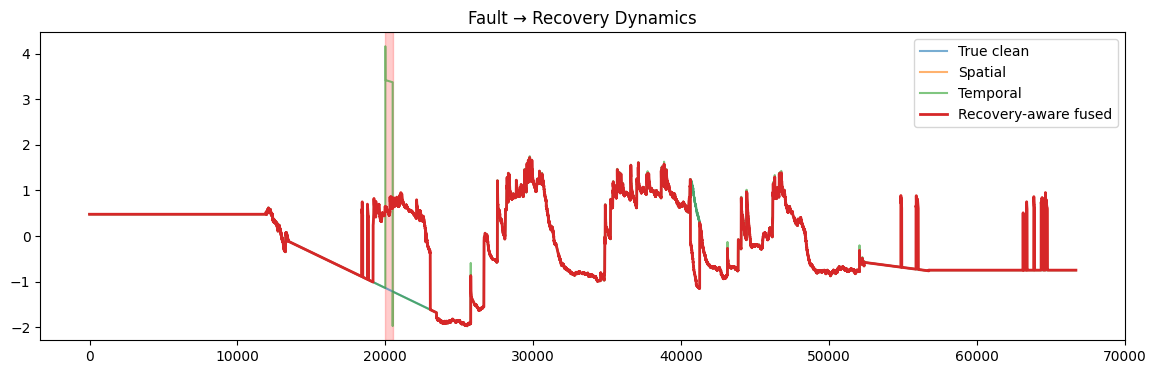

In [70]:
plt.figure(figsize=(14,4))
plt.plot(Y_true[:, sensor_idx], label="True clean", alpha=0.6)
plt.plot(X_spatial_hat[:, sensor_idx], label="Spatial", alpha=0.6)
plt.plot(X_temp_hat[:, sensor_idx], label="Temporal", alpha=0.6)
plt.plot(X_fused_recovery[:, sensor_idx], label="Recovery-aware fused", linewidth=2)

plt.axvspan(FAULT_START, FAULT_END, color="red", alpha=0.2)
plt.legend()
plt.title("Fault → Recovery Dynamics")
plt.show()


# Trust-Weighted Spatial Centroid

In [71]:
def compute_trust_scores(X_obs, X_temp_hat, eps=1e-6):
    """
    X_obs:       (T, N) observed (possibly faulty)
    X_temp_hat:  (T, N) temporal predictions
    Returns:
        trust: (T, N) in (0, 1]
    """
    diff = torch.abs(X_obs - X_temp_hat)

    # per-sensor scale (robust)
    scale = torch.median(diff, dim=0).values + eps

    trust = torch.exp(-diff / scale)
    return trust


In [72]:
# ================= TRUST SCORES =================
trust = compute_trust_scores(
    X_fault,
    X_temp_hat
)

trust = torch.exp(-diff / scale)

# numerical safety floor
trust = torch.clamp(trust, min=1e-6, max=1.0)

assert trust.shape == X_fault.shape
assert torch.isfinite(trust).all()



In [73]:
def spatial_reconstruct_trust_weighted(
    X_obs,
    fault_flags,
    nbr_idx,
    nbr_dist,
    trust,
    eps=1e-6
):
    """
    X_obs:       (T, N)
    fault_flags: (T, N) bool
    nbr_idx:     (N, K)
    nbr_dist:    (N, K)
    trust:       (T, N)
    """
    T, N = X_obs.shape
    X_hat = X_obs.clone()

    inv_dist = 1.0 / (nbr_dist + eps)   # (N, K)

    for t in range(T):
        for s in range(N):

            if not fault_flags[t, s]:
                continue

            nbrs = nbr_idx[s]           # (K,)
            geo_w = inv_dist[s]          # (K,)
            trust_w = trust[t, nbrs]     # (K,)

            w = geo_w * trust_w
            Z = w.sum() + eps
            w = w / Z

            X_hat[t, s] = torch.sum(
                w * X_obs[t, nbrs]
            )

    return X_hat


In [74]:
# ================= CONVERT NEIGHBORS TO TORCH =================
nbr_idx_torch = torch.tensor(nbr_idx, dtype=torch.long)
nbr_dist_torch = torch.tensor(nbr_dist, dtype=torch.float32)

assert nbr_idx_torch.shape == nbr_dist_torch.shape


In [75]:
X_spatial_hat_trust = spatial_reconstruct_trust_weighted(
    X_fault,
    fault_flags_t,
    nbr_idx_torch,
    nbr_dist_torch,
    trust
)


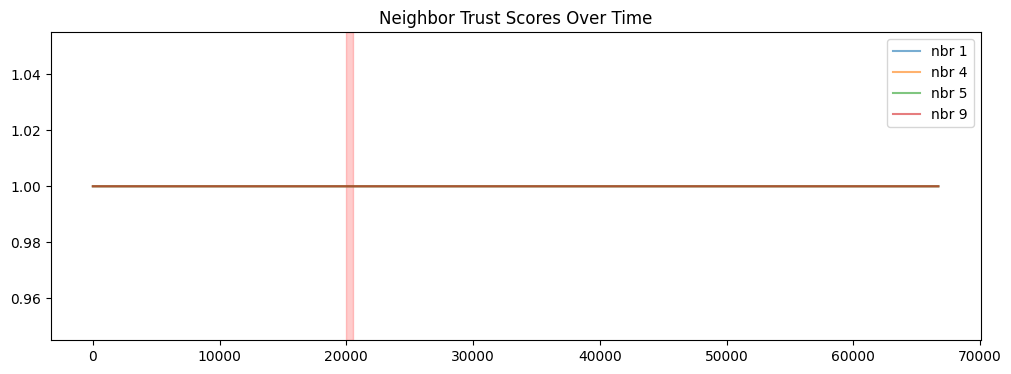

In [76]:
plt.figure(figsize=(12,4))
for n in nbr_idx[sensor_idx]:
    plt.plot(trust[:, n].cpu(), alpha=0.6, label=f"nbr {n}")

plt.axvspan(FAULT_START, FAULT_END, color="red", alpha=0.2)
plt.title("Neighbor Trust Scores Over Time")
plt.legend()
plt.show()


In [77]:
rmse_spatial_plain = torch.sqrt(
    torch.mean(
        (X_spatial_hat[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)

rmse_spatial_trust = torch.sqrt(
    torch.mean(
        (X_spatial_hat_trust[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)

print("RMSE spatial (distance only):", rmse_spatial_plain.item())
print("RMSE spatial (trust-weighted):", rmse_spatial_trust.item())


RMSE spatial (distance only): 1.7880803346633911
RMSE spatial (trust-weighted): 1.788067102432251


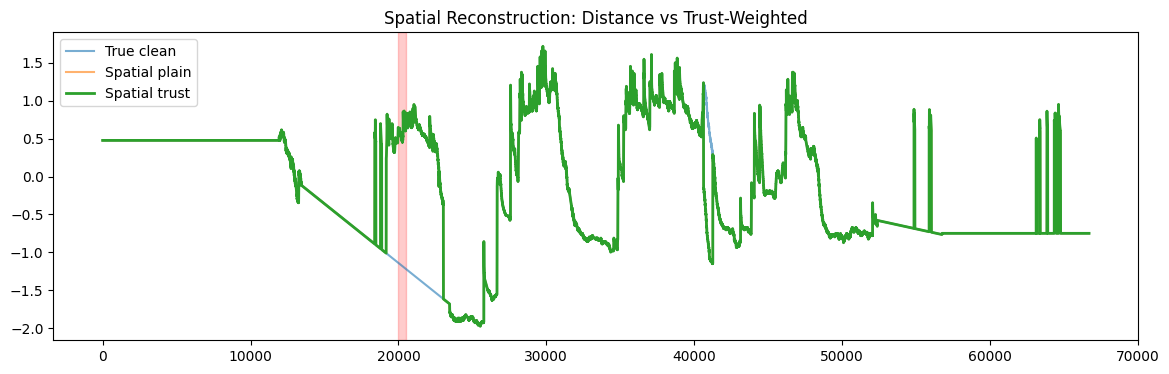

In [78]:
plt.figure(figsize=(14,4))
plt.plot(Y_true[:, sensor_idx], label="True clean", alpha=0.6)
plt.plot(X_spatial_hat[:, sensor_idx], label="Spatial plain", alpha=0.6)
plt.plot(X_spatial_hat_trust[:, sensor_idx], label="Spatial trust", linewidth=2)

plt.axvspan(FAULT_START, FAULT_END, color="red", alpha=0.2)
plt.legend()
plt.title("Spatial Reconstruction: Distance vs Trust-Weighted")
plt.show()


# Inject a Faulty Neighbor (Controlled Stress Test)

In [79]:
# ================= SELECT FAULTY NEIGHBOR =================
target = sensor_idx

# pick the first spatial neighbor of the target
faulty_neighbor = int(nbr_idx[target][0])

print("Target sensor:", target)
print("Faulty neighbor:", faulty_neighbor)


Target sensor: 2
Faulty neighbor: 1


In [80]:
# ================= NEIGHBOR FAULT INJECTION =================
NEIGHBOR_FAULT_MAG = 5.0   # same scale as before

X_fault_nb = X_fault.clone()
X_fault_nb[FAULT_START:FAULT_END, faulty_neighbor] += NEIGHBOR_FAULT_MAG

assert torch.isfinite(X_fault_nb).all()


In [81]:
# ================= TRUST (WITH FAULTY NEIGHBOR) =================
diff = torch.abs(X_fault_nb - X_temp_hat)
scale = torch.median(diff, dim=0).values + 1e-6

trust_nb = torch.exp(-diff / scale)
trust_nb = torch.clamp(trust_nb, min=1e-6, max=1.0)

print(
    "trust stats (neighbor-fault case) →",
    trust_nb.min().item(),
    trust_nb.mean().item()
)


trust stats (neighbor-fault case) → 9.999999974752427e-07 0.9319421052932739


In [82]:
X_spatial_plain_nb = spatial_reconstruct(
    X_fault_nb.numpy(),
    fault_flags,
    nbr_idx,
    W_spatial
)
X_spatial_plain_nb = torch.tensor(X_spatial_plain_nb, dtype=torch.float32)


In [83]:
X_spatial_trust_nb = spatial_reconstruct_trust_weighted(
    X_fault_nb,
    fault_flags_t,
    nbr_idx_torch,
    nbr_dist_torch,
    trust_nb
)


In [84]:
rmse_plain_nb = torch.sqrt(
    torch.mean(
        (X_spatial_plain_nb[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)

rmse_trust_nb = torch.sqrt(
    torch.mean(
        (X_spatial_trust_nb[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)

print("RMSE spatial (distance-only, neighbor faulty):", rmse_plain_nb.item())
print("RMSE spatial (trust-weighted, neighbor faulty):", rmse_trust_nb.item())


RMSE spatial (distance-only, neighbor faulty): 3.468899726867676
RMSE spatial (trust-weighted, neighbor faulty): 1.7388944625854492


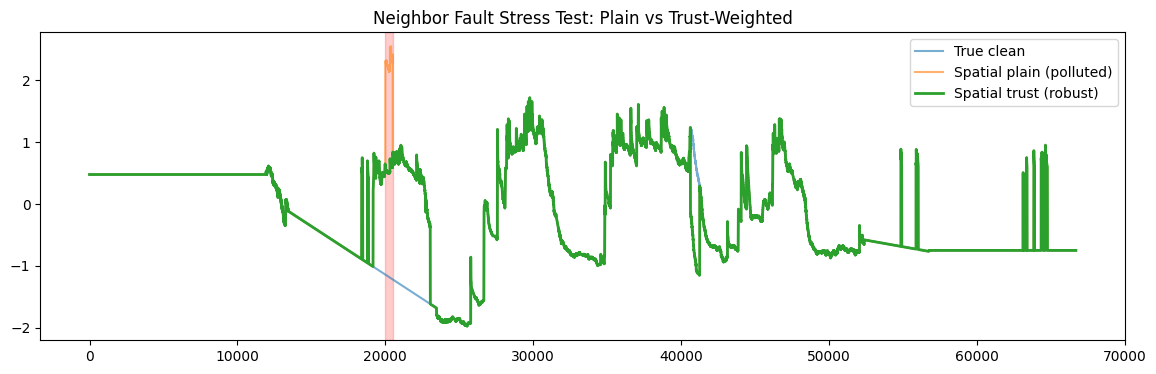

In [85]:
plt.figure(figsize=(14,4))
plt.plot(Y_true[:, sensor_idx], label="True clean", alpha=0.6)
plt.plot(X_spatial_plain_nb[:, sensor_idx], label="Spatial plain (polluted)", alpha=0.6)
plt.plot(X_spatial_trust_nb[:, sensor_idx], label="Spatial trust (robust)", linewidth=2)

plt.axvspan(FAULT_START, FAULT_END, color="red", alpha=0.2)
plt.legend()
plt.title("Neighbor Fault Stress Test: Plain vs Trust-Weighted")
plt.show()


In [86]:
# average trust during fault window
avg_trust_fault = trust_nb[mask_fault_window].mean(dim=0)

for n in nbr_idx[sensor_idx]:
    print(f"Neighbor {n}: avg trust = {avg_trust_fault[n].item():.3f}")


Neighbor 1: avg trust = 0.000
Neighbor 4: avg trust = 1.000
Neighbor 5: avg trust = 1.000
Neighbor 9: avg trust = 1.000
